# Lab 4.01 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1 - soft-drinks


The file softdrinks.xlsx categorizes 250 randomly 
selected consumers on the basis of their gender, their 
age, and their preference for our brand or a competitor's brand of a low-calorie soft drink. Use a chi-square test for independence to see whether the drink 
preference is independent of gender, and then whether 
it is independent of age.  First make a plot

Results of the main calculations:
- age vs preference
  - χ² ≈ 3.8589  
  - p-value = 0.2771
  - We do not reject H0


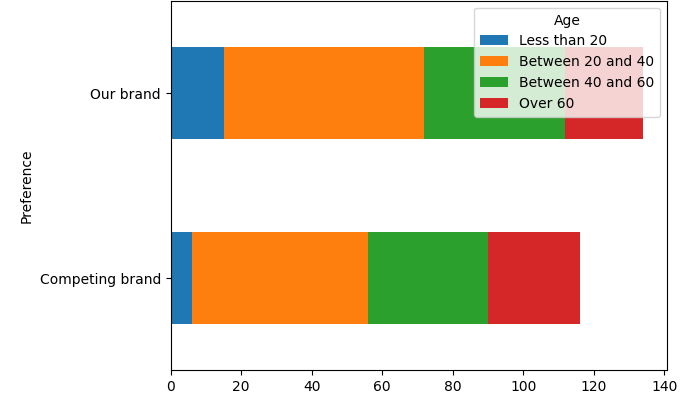



- gender vs preference
  - χ² ≈ 1.4078 
  - p-value = 0.2354
  - We do not reject H0

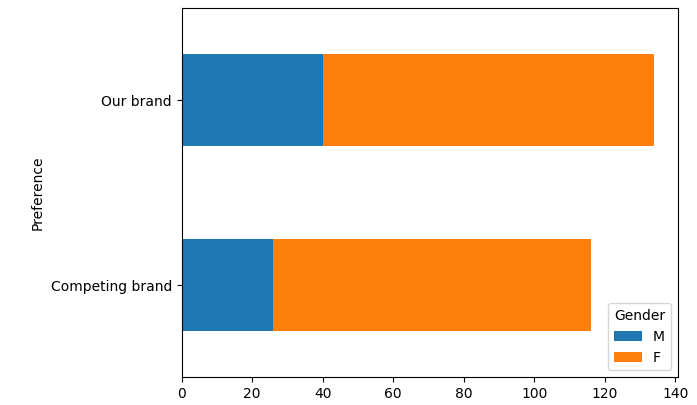

In [2]:
softdrinks = pd.read_csv(
    'https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Softdrinks.csv', 
    sep=";", index_col=0)
softdrinks.head()

,Gender,Age,Preference
Consumer,,,
1,F,Over 60,Our brand
2,F,Between 40 and 60,Our brand
3,M,Between 40 and 60,Our brand
4,F,Over 60,Competing brand
5,M,Between 20 and 40,Our brand


### Age vs Preference

H0: there is no relation between preference and age  
H1: there is a relation between preference and age

In [6]:
obs = pd.crosstab(softdrinks.Preference, softdrinks.Age)
obs

Age,Between 20 and 40,Between 40 and 60,Less than 20,Over 60
Preference,,,,
Competing brand,50,34,6,26
Our brand,57,40,15,22


<Axes: ylabel='Preference'>

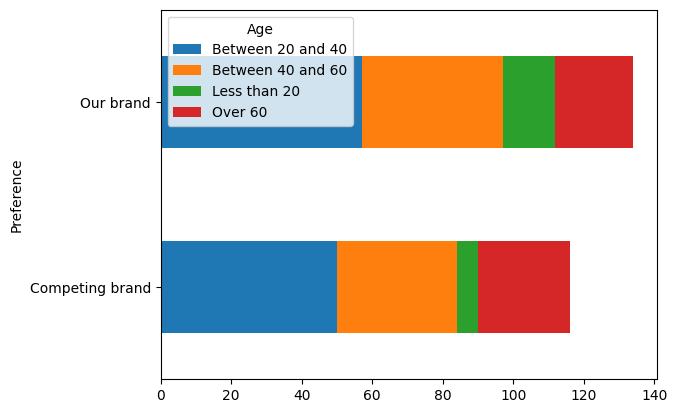

In [8]:
obs.plot(kind='barh', stacked='True')

In [21]:
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(0.05, df = dof)
print(round(chi2, 3))
print(round(p, 3))
print(round(g, 3))

1.408
0.235
3.841


chi2 is too small and p is alot more than 0.05 (alpha). So we do not reject H0.

### Gender vs Preference

H0: there is no relation between preference and gender  
H1: there is a relation between preference and gender

In [ ]:
obs = pd.crosstab(softdrinks.Preference, softdrinks.Gender)
obs

Gender,F,M
Preference,,
Competing brand,90,26
Our brand,94,40


<Axes: ylabel='Preference'>

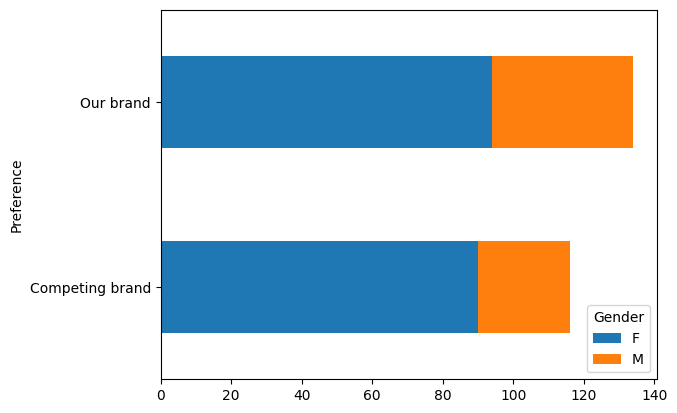

In [15]:
obs.plot(kind='barh', stacked=True)

In [19]:
chi2, p, dof, expected = stats.chi2_contingency(obs)
g = stats.chi2.isf(0.05, df = dof)
print(round(chi2, 3))
print(round(p, 3))
print(round(g, 3))

1.408
0.235
3.841


p is larger than alpha so we do not reject H0

**Remark** - If you calculate the chi squared statistic step by step with the worked out procedure in `4.01-chi-squared.ipynb`, you will get a different value than when you use `scipy.stats.chi2_contingency()`. This is because the latter applies Yates' correction for continuity, which is a correction applied to the chi-squared test when dealing with 2x2 contingency tables. The correction is designed to reduce the bias in the chi-squared statistic that can occur when the sample size is small. You can disable this correction in `scipy.stats.chi2_contingency()` by setting the `correction` parameter to `False`. If you do this, you should get these results:

- $\chi^2 \approx$ 1.7698
- $g \approx$ 3.8415
- $p \approx$ 0.1834
